# 📊 Sourcing des Données ImmoAsk

**Objectif**: Extraire les données de l'API ImmoAsk et les préparer pour Looker Studio

---

## 🚀 Guide d'utilisation

**Exécutez les cellules dans l'ordre** en appuyant sur `Shift + Enter`

## 📦 Étape 1 : Installation des bibliothèques

Exécutez cette cellule **une seule fois** pour installer les dépendances nécessaires.

In [1]:
# Installation des bibliothèques (à exécuter une seule fois)
!pip install requests pandas --quiet

## 📥 Étape 2 : Importer les bibliothèques

In [2]:
import requests
import pandas as pd
import json
from datetime import datetime

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


## 🔧 Étape 3 : Définir la classe de sourcing

Cette classe gère toute la logique d'extraction et de transformation.

In [3]:
class ImmoAskDataSourcing:
    """Classe pour gérer l'extraction et la transformation des données ImmoAsk"""
    
    def __init__(self, limit=200):
        self.base_url = "https://devapi.omnisoft.africa/public/api/v2"
        self.limit = limit
        self.raw_data = None
        self.processed_data = None
    
    def build_graphql_query(self):
        """Construit la requête GraphQL"""
        query = f"""{{getPropertiesByKeyWords(orderBy:{{order:DESC,column:NUO}},limit:{self.limit}){{surface,badge_propriete{{badge{{badge_name,badge_image}}}},id,nuo,usage,offre{{denomination}},categorie_propriete{{denomination}},piece,titre,garage,nuitee,cout_mensuel,ville{{denomination}},wc_douche_interne,cout_vente,quartier{{id,denomination,minus_denomination}},visuels{{uri,position}}}}}}"""
        return query
    
    def fetch_data(self):
        """Récupère les données de l'API"""
        query = self.build_graphql_query()
        url = f"{self.base_url}?query={query}"
        
        print(f"🔄 Récupération de {self.limit} propriétés...")
        
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        
        self.raw_data = response.json()
        count = len(self.raw_data['data']['getPropertiesByKeyWords'])
        print(f"✅ {count} propriétés récupérées avec succès!")
        
        return self.raw_data
    
    def flatten_property(self, prop):
        """Aplatit les champs imbriqués d'une propriété"""
        flat = {
            'id': prop.get('id'),
            'nuo': prop.get('nuo'),
            'usage': prop.get('usage'),
            'piece': prop.get('piece'),
            'titre': prop.get('titre'),
            'garage': prop.get('garage'),
            'nuitee': prop.get('nuitee'),
            'cout_mensuel': prop.get('cout_mensuel'),
            'cout_vente': prop.get('cout_vente'),
            'surface': prop.get('surface'),
            'wc_douche_interne': prop.get('wc_douche_interne'),
            'offre': prop['offre']['denomination'] if prop.get('offre') else None,
            'categorie': prop['categorie_propriete']['denomination'] if prop.get('categorie_propriete') else None,
            'ville': prop['ville']['denomination'] if prop.get('ville') else None,
        }
        
        # Quartier
        if prop.get('quartier'):
            flat['quartier_id'] = prop['quartier'].get('id')
            flat['quartier'] = prop['quartier'].get('denomination')
        else:
            flat['quartier_id'] = None
            flat['quartier'] = None
        
        # Badges
        if prop.get('badge_propriete') and len(prop['badge_propriete']) > 0:
            flat['badge_name'] = prop['badge_propriete'][0]['badge']['badge_name']
            flat['nb_badges'] = len(prop['badge_propriete'])
        else:
            flat['badge_name'] = None
            flat['nb_badges'] = 0
        
        # Visuels
        if prop.get('visuels') and len(prop['visuels']) > 0:
            flat['nb_visuels'] = len(prop['visuels'])
            flat['premier_visuel'] = prop['visuels'][0]['uri']
        else:
            flat['nb_visuels'] = 0
            flat['premier_visuel'] = None
        
        return flat
    
    def transform_data(self):
        """Transforme les données en DataFrame"""
        if not self.raw_data:
            raise ValueError("Pas de données. Exécutez fetch_data() d'abord")
        
        print("🔄 Transformation des données...")
        
        properties = self.raw_data['data']['getPropertiesByKeyWords']
        flattened = [self.flatten_property(p) for p in properties]
        
        df = pd.DataFrame(flattened)
        
        # Conversion des types numériques
        for col in ['surface', 'piece', 'garage', 'nuitee', 'cout_mensuel', 'cout_vente', 'nb_badges', 'nb_visuels']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        self.processed_data = df
        print(f"✅ Transformation terminée: {df.shape[0]} lignes × {df.shape[1]} colonnes")
        
        return df
    
    def save_to_csv(self, filename=None):
        """Sauvegarde en CSV"""
        if self.processed_data is None:
            raise ValueError("Pas de données à sauvegarder")
        
        if not filename:
            filename = f"immoask_data_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        
        self.processed_data.to_csv(filename, index=False, encoding='utf-8-sig')
        print(f"💾 Données sauvegardées: {filename}")
        return filename

print("✅ Classe ImmoAskDataSourcing définie!")

✅ Classe ImmoAskDataSourcing définie!


## 🎯 Étape 4 : Créer l'instance et récupérer les données

**Modifiez** le paramètre `limit` si vous voulez plus ou moins de 200 propriétés.

In [15]:
# Créer l'instance (vous pouvez changer limit=200 par limit=500 par exemple)
sourcing = ImmoAskDataSourcing(limit=500)

# Récupérer les données depuis l'API
sourcing.fetch_data()

🔄 Récupération de 500 propriétés...
✅ 500 propriétés récupérées avec succès!


{'data': {'getPropertiesByKeyWords': [{'surface': 120,
    'badge_propriete': [{'badge': {'badge_name': 'Nouvel',
       'badge_image': 'info'}}],
    'id': '1566',
    'nuo': 5506,
    'usage': 'Logement',
    'offre': {'denomination': 'louer'},
    'categorie_propriete': {'denomination': 'Appartement'},
    'piece': 3,
    'titre': 'Villa Lomé',
    'garage': 1,
    'nuitee': 50,
    'cout_mensuel': 500,
    'ville': {'denomination': 'Tsevie'},
    'wc_douche_interne': 1,
    'cout_vente': 0,
    'quartier': None,
    'visuels': [{'uri': 'GqwUrvXEBiAS3Og5iSQcFDjp9zme7LEAAG546pyr.jpg',
      'position': 1},
     {'uri': 'Vjqh90RVPeGYbKmXxob9yLQsBG8UBUyIlPKMtOc9.jpg', 'position': 2}]},
   {'surface': 50,
    'badge_propriete': [{'badge': {'badge_name': 'Nouvel',
       'badge_image': 'info'}}],
    'id': '1565',
    'nuo': 5505,
    'usage': 'Logement',
    'offre': {'denomination': 'louer'},
    'categorie_propriete': {'denomination': 'Boutique'},
    'piece': 1,
    'titre': '',
    

## 🔄 Étape 5 : Transformer les données en DataFrame

In [16]:
# Transformer les données
df = sourcing.transform_data()

# Afficher les premières lignes
df.head()

🔄 Transformation des données...
✅ Transformation terminée: 500 lignes × 20 colonnes


,id,nuo,usage,piece,titre,garage,nuitee,cout_mensuel,cout_vente,surface,wc_douche_interne,offre,categorie,ville,quartier_id,quartier,badge_name,nb_badges,nb_visuels,premier_visuel
0,1566,5506,Logement,3,Villa Lomé,1,50,500,0,120.0,1,louer,Appartement,Tsevie,None,None,Nouvel,1,2,GqwUrvXEBiAS3Og5iSQcFDjp9zme7LEAAG546pyr.jpg
1,1565,5505,Logement,1,,0,0,70000,0,50.0,1,louer,Boutique,Lome,3,Baguida,Nouvel,1,1,02APkDeDrlsSx1zY9shR13mG8MBbHX9YVrpJEksE.jpg
2,1564,5504,Logement,3,,2,0,250000,0,104.0,3,louer,Villa,Lome,4,Agoe,Nouvel,1,1,gmcF7Xi4F4ogb3LsuodT9OUICJphBUvU8CWZeqeY.jpg
3,1563,5503,Logement,0,,0,0,5003,0,10.0,0,louer,Espace commercial,Tabligbo,243,Kpomé,Nouvel,1,3,zyiTZi0D9Yrml9yGonX7SI3JUZEIlww7NVzoghtt.png
4,1562,5502,Logement,0,,0,0,5003,0,10.0,0,louer,Espace commercial,Tabligbo,243,Kpomé,Nouvel,1,3,ODUehFJG8GWH4Q4i9fczBPjUoMFQaDpzmuzUwWeA.png


## 👀 Étape 6 : Explorer les données

In [17]:
# Informations sur le DataFrame
print("📊 INFORMATIONS SUR LES DONNÉES")
print("=" * 50)
print(f"Nombre de propriétés: {len(df)}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"\nColonnes disponibles:")
print(df.columns.tolist())

📊 INFORMATIONS SUR LES DONNÉES
Nombre de propriétés: 500
Nombre de colonnes: 20

Colonnes disponibles:
['id', 'nuo', 'usage', 'piece', 'titre', 'garage', 'nuitee', 'cout_mensuel', 'cout_vente', 'surface', 'wc_douche_interne', 'offre', 'categorie', 'ville', 'quartier_id', 'quartier', 'badge_name', 'nb_badges', 'nb_visuels', 'premier_visuel']


In [18]:
# Statistiques descriptives
df.describe()

,nuo,piece,garage,nuitee,cout_mensuel,cout_vente,surface,wc_douche_interne,nb_badges,nb_visuels
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,5256.500000,0.958000,0.538000,1394.100000,4.618010e+05,1.425140e+07,1419.295000,1.204000,0.084000,3.670000
std,144.481833,1.562408,0.818472,8774.763994,2.874332e+06,7.405719e+07,21939.460301,1.145866,0.277666,2.089457
min,5007.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,10.000000,0.000000,0.000000,1.000000
25%,5131.750000,0.000000,0.000000,0.000000,3.000000e+04,0.000000e+00,60.000000,0.000000,0.000000,3.000000
50%,5256.500000,0.000000,0.000000,0.000000,2.000000e+05,0.000000e+00,150.000000,1.000000,0.000000,3.000000
75%,5381.250000,2.000000,1.000000,0.000000,3.500000e+05,0.000000e+00,300.000000,2.000000,0.000000,4.000000
max,5506.000000,13.000000,4.000000,79000.000000,4.500000e+07,1.050000e+09,490000.000000,6.000000,1.000000,16.000000


## 📊 Étape 7 : Analyses rapides

In [19]:
# Répartition par type d'offre
print("🏠 RÉPARTITION PAR TYPE D'OFFRE")
print("=" * 50)
print(df['offre'].value_counts())
print("\n")

# Répartition par ville (Top 10)
print("🌆 RÉPARTITION PAR VILLE (Top 10)")
print("=" * 50)
print(df['ville'].value_counts().head(10))
print("\n")

# Répartition par catégorie
print("🏢 RÉPARTITION PAR CATÉGORIE")
print("=" * 50)
print(df['categorie'].value_counts())

🏠 RÉPARTITION PAR TYPE D'OFFRE
offre
louer      387
vendre     109
bailler      4
Name: count, dtype: int64


🌆 RÉPARTITION PAR VILLE (Top 10)
ville
Lome        476
Kpalime       9
Afagnan       5
Aneho         4
Tabligbo      3
Tsevie        2
Akepe         1
Name: count, dtype: int64


🏢 RÉPARTITION PAR CATÉGORIE
categorie
Appartement meublé     170
Villa                   85
Terrain                 76
Chambre salon           43
Villa meublée           41
Appartement             28
2 chambres salon        14
Maison                  13
Chambre                  6
Boutique                 4
3 chambres salon         4
Terrain urbain           3
Espace commercial        3
Bureau                   2
Studio                   2
Magasin                  2
Studio meublé            2
Immeuble                 1
Immeuble commercial      1
Name: count, dtype: int64


In [20]:
# Statistiques sur les prix
print("💰 STATISTIQUES SUR LES PRIX")
print("=" * 50)

if 'cout_vente' in df.columns:
    stats_vente = df['cout_vente'].describe()
    print("\nPrix de vente:")
    print(f"  Moyenne: {stats_vente['mean']:,.0f} FCFA")
    print(f"  Médiane: {stats_vente['50%']:,.0f} FCFA")
    print(f"  Min: {stats_vente['min']:,.0f} FCFA")
    print(f"  Max: {stats_vente['max']:,.0f} FCFA")

if 'cout_mensuel' in df.columns:
    stats_loyer = df['cout_mensuel'].describe()
    print("\nLoyer mensuel:")
    print(f"  Moyenne: {stats_loyer['mean']:,.0f} FCFA")
    print(f"  Médiane: {stats_loyer['50%']:,.0f} FCFA")

💰 STATISTIQUES SUR LES PRIX

Prix de vente:
  Moyenne: 14,251,400 FCFA
  Médiane: 0 FCFA
  Min: 0 FCFA
  Max: 1,050,000,000 FCFA

Loyer mensuel:
  Moyenne: 461,801 FCFA
  Médiane: 200,000 FCFA


## 🔍 Étape 8 : Filtrer les données (optionnel)

Exemples de filtres que vous pouvez appliquer :

In [21]:
# Filtrer par ville (exemple: Lomé)
df_lome = df[df['ville'] == 'Lomé']
print(f"Propriétés à Lomé: {len(df_lome)}")

# Filtrer par type d'offre (exemple: Vente)
df_vente = df[df['offre'] == 'Vente']
print(f"Propriétés en vente: {len(df_vente)}")

# Filtrer par prix (exemple: moins de 50 millions)
df_budget = df[df['cout_vente'] < 50000000]
print(f"Propriétés < 50M FCFA: {len(df_budget)}")

# Afficher un aperçu des propriétés à Lomé
df_lome.head()

Propriétés à Lomé: 0
Propriétés en vente: 0
Propriétés < 50M FCFA: 475


,id,nuo,usage,piece,titre,garage,nuitee,cout_mensuel,cout_vente,surface,wc_douche_interne,offre,categorie,ville,quartier_id,quartier,badge_name,nb_badges,nb_visuels,premier_visuel


## 💾 Étape 9 : Sauvegarder les données

**Important**: C'est ici que vous créez le fichier CSV pour Looker Studio!

In [ ]:
# Sauvegarder toutes les données
filename = sourcing.save_to_csv('immoask_complet.csv')

# OU sauvegarder un sous-ensemble (par exemple, uniquement Lomé)
# df_lome.to_csv('Immoask-lome.csv', index=False, encoding='utf-8-sig')
# print("💾 Données Lomé sauvegardées: immoask_lome.csv")

💾 Données sauvegardées: immoask_complet.csv


## 📈 Étape 10 : Visualisations rapides (optionnel)

Quelques graphiques pour mieux comprendre vos données.

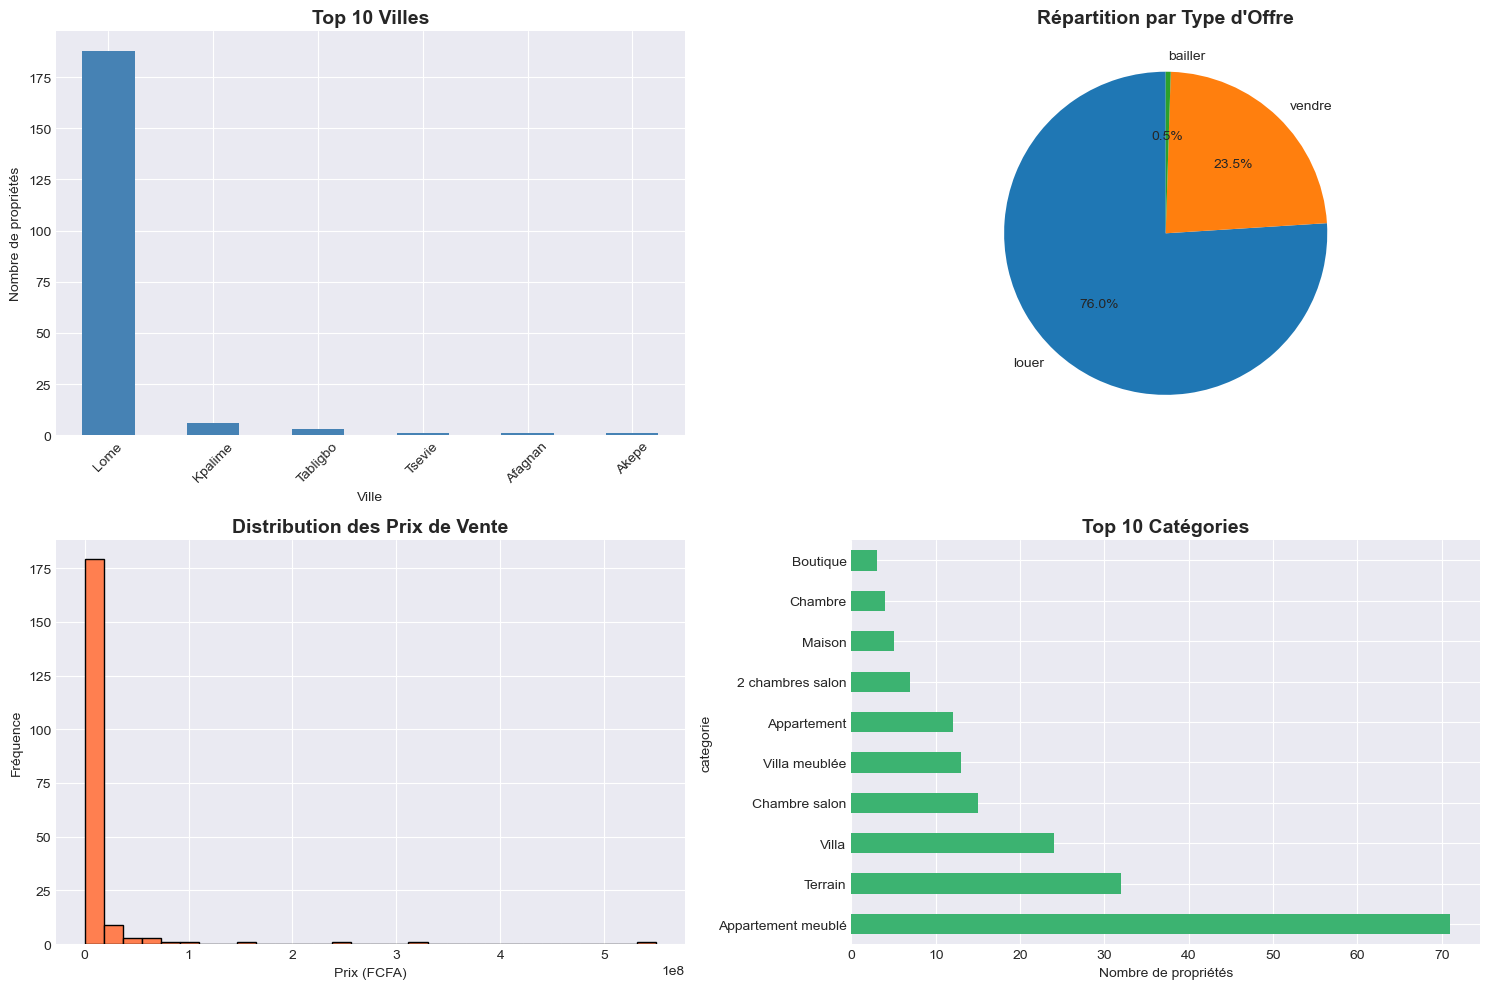

In [12]:
import matplotlib.pyplot as plt

# Configurer le style
plt.style.use('seaborn-v0_8-darkgrid')

# Graphique 1: Répartition par ville (Top 10)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 villes
df['ville'].value_counts().head(10).plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Top 10 Villes', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Ville')
axes[0, 0].set_ylabel('Nombre de propriétés')
axes[0, 0].tick_params(axis='x', rotation=45)

# Répartition par offre
df['offre'].value_counts().plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Répartition par Type d\'Offre', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('')

# Distribution des prix de vente
df['cout_vente'].dropna().plot(kind='hist', bins=30, ax=axes[1, 0], color='coral', edgecolor='black')
axes[1, 0].set_title('Distribution des Prix de Vente', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Prix (FCFA)')
axes[1, 0].set_ylabel('Fréquence')

# Répartition par catégorie
df['categorie'].value_counts().head(10).plot(kind='barh', ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title('Top 10 Catégories', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Nombre de propriétés')

plt.tight_layout()
plt.show()

## ✅ Récapitulatif

### Ce que vous avez fait:
1. ✅ Installé les bibliothèques nécessaires
2. ✅ Récupéré les données depuis l'API ImmoAsk
3. ✅ Transformé les données en format tabulaire
4. ✅ Exploré et analysé les données
5. ✅ Sauvegardé les données en CSV

### Prochaines étapes:
1. 📊 Utiliser le fichier CSV créé pour votre connecteur Looker Studio
2. 🔧 Créer le Community Connector en suivant la documentation Google
3. 🎯 Construire vos tableaux de bord dans Looker Studio

---

**Besoin d'aide?** Relancez les cellules ou modifiez les paramètres selon vos besoins!

## 🔧 Cellule bonus : Analyses personnalisées

Utilisez cette cellule pour vos propres analyses :

In [14]:
import pandas as pd
df = pd.read_csv("immoask_complet.csv", encoding='utf-8-sig')
df.to_excel("immoask_data.xlsx", index=False, engine='openpyxl')

In [13]:
# Votre code d'analyse personnalisée ici
# Exemple: Prix moyen par ville

prix_par_ville = df.groupby('ville')['cout_vente'].mean().sort_values(ascending=False)
print("💰 Prix moyen de vente par ville (Top 10):")
print(prix_par_ville.head(10))

💰 Prix moyen de vente par ville (Top 10):
ville
Lome        1.169309e+07
Kpalime     5.500000e+05
Afagnan     0.000000e+00
Akepe       0.000000e+00
Tabligbo    0.000000e+00
Tsevie      0.000000e+00
Name: cout_vente, dtype: float64
